# 1. Data Audit and Exploratory Data Analysis

## Project
Airbnb Price Prediction Using Machine Learning

## Dataset
London Airbnb Detailed Listings Dataset from Inside Airbnb

## Objective
This notebook performs initial data auditing and exploratory data analysis on the raw Airbnb dataset. The analysis includes dataset structure, missing values, duplicate records, statistical summaries, price distribution, and identification of potential data quality issues before preprocessing.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load raw Airbnb dataset

df = pd.read_csv(
    "../data/raw/listings.csv"
)

print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
# Dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 92638
Number of columns: 90


In [5]:
# Display first five records

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11551,https://www.airbnb.com/rooms/11551,20260619061251,2026-06-25,city scrape,Artistic London Pied-à-Terre,Live like a local in this quintessential Londo...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,43039,...,4.84,4.54,4.49,NaN,NaN,1,1,0,0,0.99
1,13913,https://www.airbnb.com/rooms/13913,20260619061251,2026-06-25,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.88,4.79,4.79,NaN,NaN,2,1,1,0,0.30
2,15400,https://www.airbnb.com/rooms/15400,20260619061251,2026-06-26,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,NaN,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.84,4.94,4.74,NaN,NaN,1,1,0,0,0.49
3,17402,https://www.airbnb.com/rooms/17402,20260619061251,2026-06-29,city scrape,Spacious Fitzrovia 3bed/2bath By Soho & Oxford St,"Stay in this spacious 3-bedroom, 2-bath apartm...",NaN,https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,4.73,4.89,4.62,NaN,NaN,2,2,0,0,0.31
4,513198,https://www.airbnb.com/rooms/513198,20260619061251,2026-06-29,city scrape,Stunning views over Central London! (room),Wake up to the sound of Big Ben!<br /><br />Th...,NaN,https://a0.muscache.com/pictures/6442310/e4b3e...,2528030,...,4.74,4.72,4.42,NaN,NaN,2,1,1,0,0.25


In [6]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            92638 non-null  int64  
 1   listing_url                                   92638 non-null  str    
 2   scrape_id                                     92638 non-null  int64  
 3   last_scraped                                  92638 non-null  str    
 4   source                                        92638 non-null  str    
 5   name                                          92638 non-null  str    
 6   description                                   90549 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   92633 non-null  str    
 9   host_id                                       92638 non-null  int64  
 1

In [7]:
# Missing value analysis

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

missing_table = (
    missing_table[missing_table["Missing Count"] > 0]
    .sort_values(
        by="Missing Percentage",
        ascending=False
    )
)

missing_table.head(20)

,Missing Count,Missing Percentage
neighborhood_overview,92638,100.000000
host_since,92638,100.000000
host_neighbourhood,92638,100.000000
host_total_listings_count,92638,100.000000
neighbourhood,92638,100.000000
host_verifications,92638,100.000000
host_response_rate,92638,100.000000
host_acceptance_rate,92638,100.000000
host_thumbnail_url,92638,100.000000
host_response_time,92638,100.000000


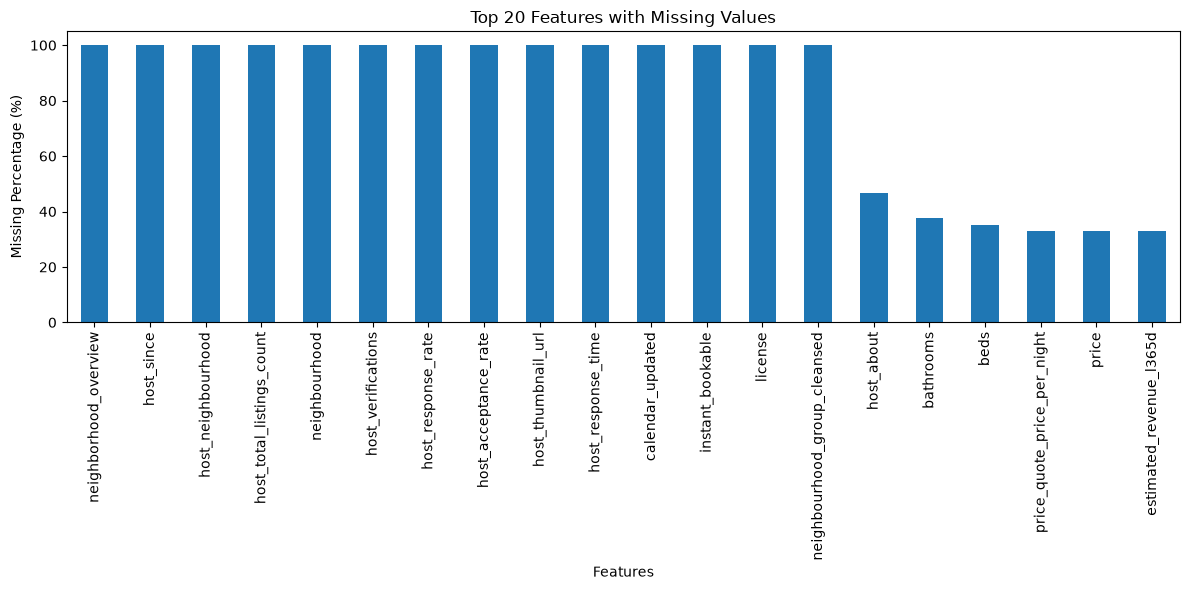

In [8]:
plt.figure(figsize=(12,6))

missing_table.head(20)["Missing Percentage"].plot(
    kind="bar"
)

plt.title("Top 20 Features with Missing Values")
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Features")

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    "../figures/missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## Price Distribution Analysis

The price column is the prediction target. Before preprocessing, the raw price distribution is analyzed to identify missing values, invalid entries, and extreme values.

In [10]:
# Inspect raw price values

df["price"].head()

0    $234.50
1    $127.00
2    $137.50
3    $606.67
4     $68.30
Name: price, dtype: str

In [16]:
# Convert price from string to numerical format

df["price_clean"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["price_clean"].head()

0    234.50
1    127.00
2    137.50
3    606.67
4     68.30
Name: price_clean, dtype: float64

In [17]:
# Check missing price values

missing_price = df["price_clean"].isnull().sum()

print("Missing price values:", missing_price)

Missing price values: 30398


In [18]:
# Check zero or negative prices

invalid_price = df[
    (df["price_clean"].isnull()) |
    (df["price_clean"] <= 0)
]

print("Invalid price records:", len(invalid_price))

Invalid price records: 30398


In [19]:
# Price descriptive statistics

df["price_clean"].describe()

count     62240.000000
mean        271.469220
std        2190.599006
min           2.230000
25%         100.000000
50%         180.000000
75%         300.032500
max      527524.000000
Name: price_clean, dtype: float64

In [20]:
# Highest priced listings

df["price_clean"].sort_values(
    ascending=False
).head(10)

67130    527524.0
8400      75000.0
61588     59214.0
57238     28000.0
56041     23686.0
57946     19150.0
64156     16316.8
56739     14744.0
66648     13600.0
34627     13209.0
Name: price_clean, dtype: float64

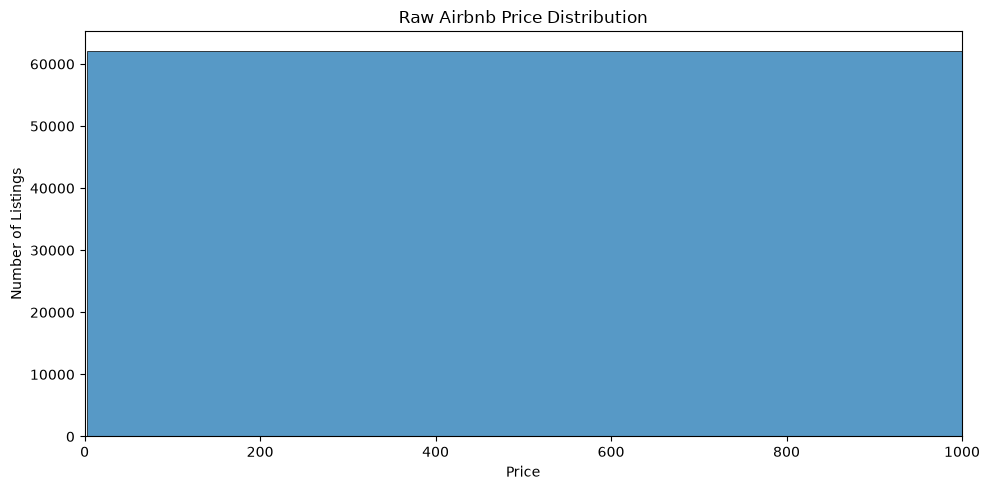

In [21]:
# Raw price distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df["price_clean"].dropna(),
    bins=100
)

plt.title("Raw Airbnb Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Listings")

plt.xlim(0,1000)

plt.tight_layout()

plt.savefig(
    "../figures/raw_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Average price by room type

room_price = (
    df.groupby("room_type")["price_clean"]
    .median()
    .sort_values()
)

room_price

room_type
Shared room         44.000
Private room        82.265
Hotel room         156.000
Entire home/apt    239.500
Name: price_clean, dtype: float64

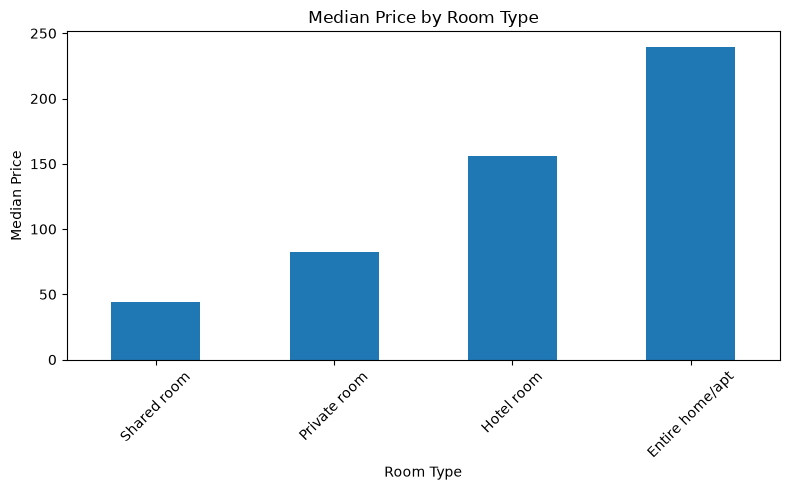

In [23]:
plt.figure(figsize=(8,5))

room_price.plot(
    kind="bar"
)

plt.title("Median Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Median Price")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../figures/price_by_room_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# Top neighbourhoods by median price

neighbourhood_price = (
    df.groupby("neighbourhood_cleansed")["price_clean"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

neighbourhood_price

neighbourhood_cleansed
City of London            325.000
Westminster               307.000
Kensington and Chelsea    305.000
Camden                    219.000
Hammersmith and Fulham    199.500
Wandsworth                194.290
Islington                 186.420
Richmond upon Thames      181.170
Tower Hamlets             170.000
Hackney                   167.190
Southwark                 166.000
Newham                    164.250
Lambeth                   164.165
Merton                    160.000
Brent                     150.000
Name: price_clean, dtype: float64

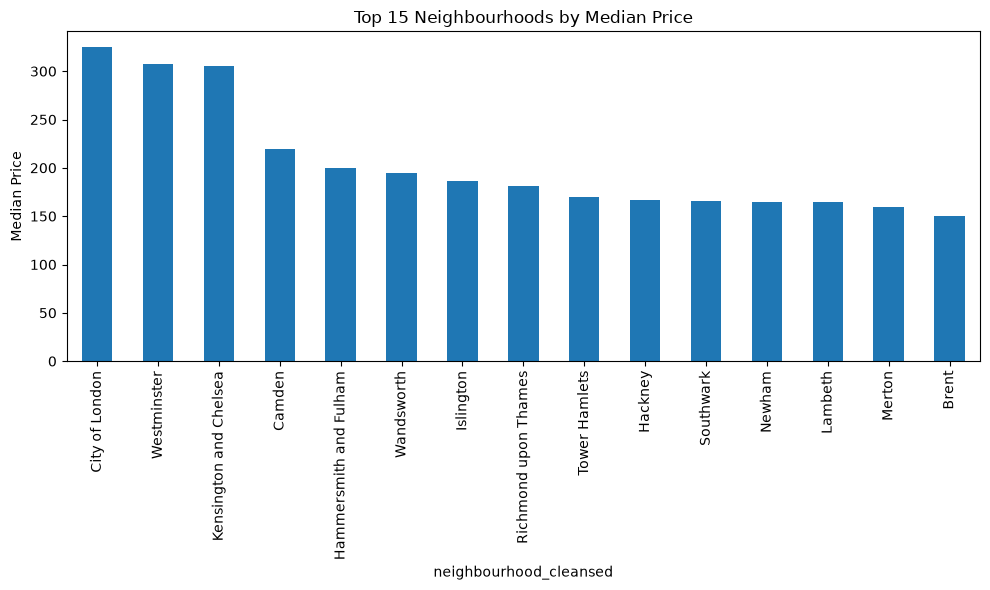

In [25]:
plt.figure(figsize=(10,6))

neighbourhood_price.plot(
    kind="bar"
)

plt.title("Top 15 Neighbourhoods by Median Price")
plt.ylabel("Median Price")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../figures/neighbourhood_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

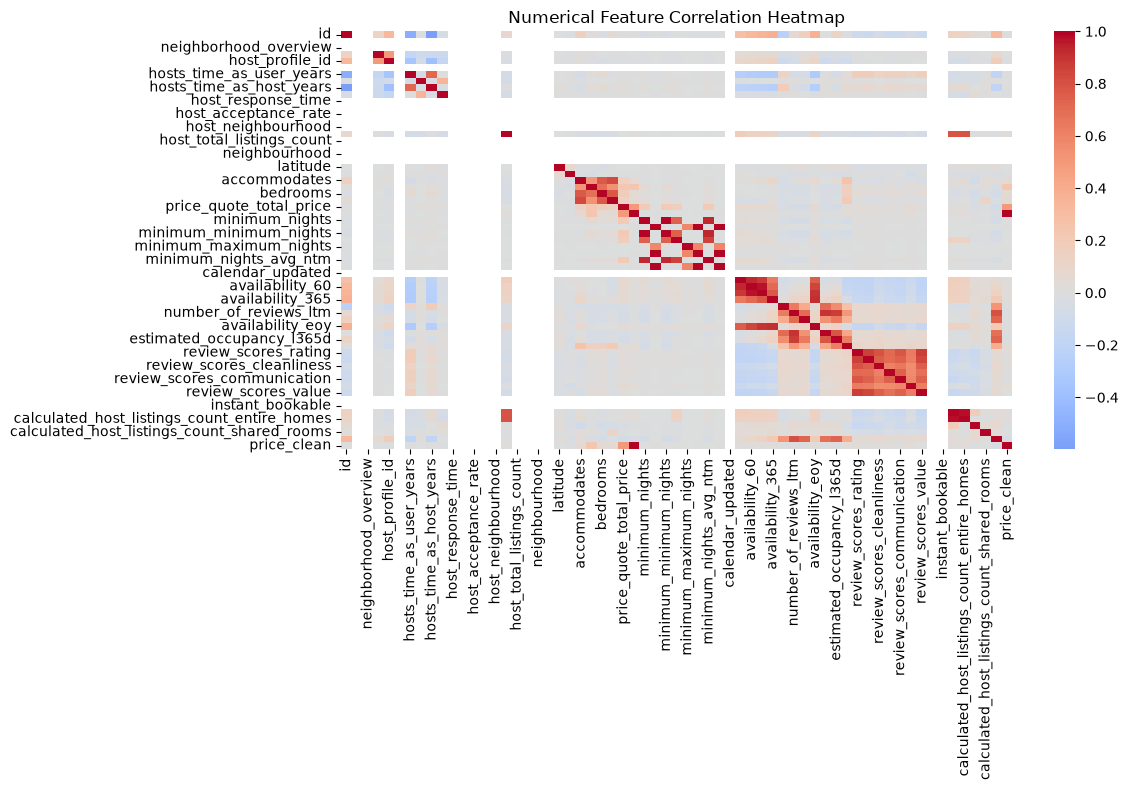

In [26]:
# Correlation heatmap

numerical_cols = df.select_dtypes(
    include=["int64","float64"]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numerical_cols.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()